In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from fredapi import Fred

In [5]:
#download market data
start = "2007-01-01"
end = "2026-01-01"

tickers = {
    "Gold": "GC=F",
    "Brent": "BZ=F",
    "VIX": "^VIX",
    "DXY": "DX-Y.NYB"
}

raw = yf.download(list(tickers.values()), start=start, end=end)["Close"]
raw.columns = tickers.keys()

fred = Fred(api_key="2d4d51600ccdd83f327ec54d649fe220 ")
yield_10y = fred.get_series("DFII10")
yield_10y = pd.DataFrame(yield_10y, columns=["RealYield"])
yield_10y.index = pd.to_datetime(yield_10y.index)

data = raw.merge(yield_10y, left_index=True, right_index=True, how="left")
data = data.ffill().dropna()
data


[*********************100%***********************]  4 of 4 completed


,Gold,Brent,VIX,DXY,RealYield
2007-07-30,75.739998,80.849998,664.099976,20.870001,2.49
2007-07-31,77.050003,80.769997,666.900024,23.520000,2.44
2007-08-01,75.349998,80.870003,663.599976,23.670000,2.44
2007-08-02,75.760002,80.709999,664.599976,21.219999,2.46
2007-08-03,74.750000,80.180000,672.500000,25.160000,2.44
...,...,...,...,...,...
2025-12-24,62.240002,97.980003,4480.600098,13.470000,1.91
2025-12-26,60.639999,98.019997,4529.100098,13.600000,1.91
2025-12-29,61.939999,98.040001,4325.100098,14.200000,1.90
2025-12-30,61.919998,98.239998,4370.100098,14.330000,1.90


Log Returns

In [32]:
returns = np.log(data / data.shift(1)).dropna()
returns.describe()
returns.kurt()

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Gold         13.027564
Brent         2.210835
VIX           5.421942
DXY           6.506200
RealYield          NaN
dtype: float64

Volatility

In [39]:
vol_20 = gold.rolling(20).std() * np.sqrt(252) 
vol_30 = gold.rolling(30).std() * np.sqrt(252)

Correlation + Beta

In [31]:
#rolling correlation

gold = returns["Gold"]
brent = returns["Brent"]
dxy = returns["DXY"]
vix = returns["VIX"]

corr_gb = gold.rolling(60).corr(brent)
corr_gd = gold.rolling(60).corr(dxy)
corr_gv = gold.rolling(60).corr(vix)

#beta (market sensitivity)
import statsmodels.api as sm

def rolling_beta(y, x, window=60):
    betas = []
    idx = []

    for i in range(window, len(y)):
        y_win = y.iloc[i-window:i]
        x_win = x.iloc[i-window:i]

        X = sm.add_constant(x_win)
        model = sm.OLS(y_win, X).fit()

        betas.append(model.params.iloc[1])
        idx.append(y.index[i])

    return pd.Series(betas, index=idx)

Rolling R-squared

In [41]:
def rolling_r2(y, x, window=60):

    r2_values = []
    dates = []

    for i in range(window, len(y)):

        # rolling window
        y_window = y.iloc[i-window:i]
        x_window = x.iloc[i-window:i]

        # combine + clean
        df = pd.concat([y_window, x_window], axis=1)
        df = df.replace([np.inf, -np.inf], np.nan).dropna()

        # skip unstable windows
        if len(df) < window * 0.8:
            continue

        y_clean = df.iloc[:, 0]
        x_clean = df.iloc[:, 1]

        # avoid constant series
        if y_clean.std() == 0 or x_clean.std() == 0:
            continue

        # regression
        X = sm.add_constant(x_clean)

        try:
            model = sm.OLS(y_clean, X).fit()

            r2_values.append(model.rsquared)
            dates.append(y.index[i])

        except:
            continue

    return pd.Series(r2_values, index=dates)

r2_brent = rolling_r2(gold, brent)
r2_vix = rolling_r2(gold, vix)
r2_dxy = rolling_r2(gold, dxy)

Z-score

In [34]:
#gold z-score
window = 60

gold_mean = gold.rolling(window).mean()
gold_std = gold.rolling(window).std()
gold_z = (gold - gold_mean) / gold_std

corr_z = (corr_gb - corr_gb.rolling(60).mean()) / corr_gb.rolling(60).std()

print(gold_z)
print(corr_z)

2007-07-31         NaN
2007-08-01         NaN
2007-08-02         NaN
2007-08-03         NaN
2007-08-06         NaN
                ...   
2025-12-24   -0.065747
2025-12-26   -1.606158
2025-12-29    1.403332
2025-12-30    0.023565
2025-12-31   -1.044938
Name: Gold, Length: 4605, dtype: float64
2007-07-31         NaN
2007-08-01         NaN
2007-08-02         NaN
2007-08-03         NaN
2007-08-06         NaN
                ...   
2025-12-24   -1.304260
2025-12-26   -1.331451
2025-12-29   -1.207596
2025-12-30   -1.139465
2025-12-31   -1.283014
Length: 4605, dtype: float64


Regime Signal

In [35]:
signal = pd.DataFrame({
    "Gold_Z": gold_z,
    "Corr_GB": corr_gb,
    "Corr_GV": corr_gv,
    "Corr_GD": corr_gd,
})

#normalize
signal_z = (signal - signal.rolling(60).mean()) / signal.rolling(60).std()

#final risk score
signal["RiskScore"] = (
    abs(signal_z["Gold_Z"]) +
    abs(signal_z["Corr_GB"]) +
    abs(signal_z["Corr_GV"]) +
    abs(signal_z["Corr_GD"])
)

detection system

In [36]:
def regime(x):
    if x < 1:
        return "Green"
    elif x < 2:
        return "Amber"
    else:
        return "Red"

signal["Regime"] = signal["RiskScore"].apply(regime)

Market Behaviour

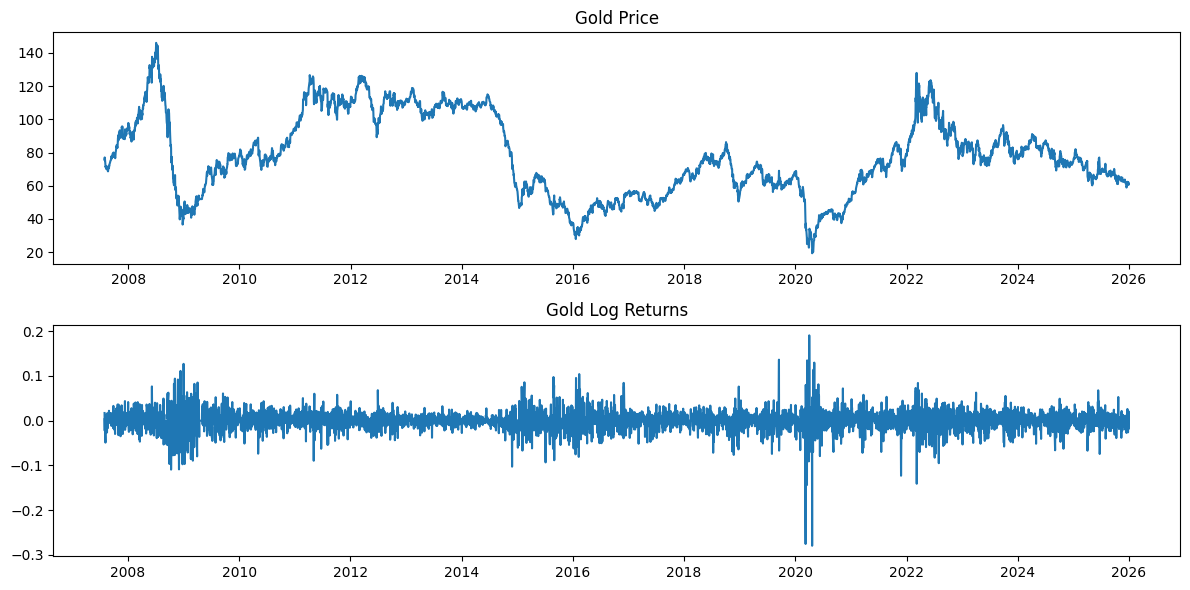

In [37]:
#gold price + returns
fig, ax = plt.subplots(2, 1, figsize=(12,6))

ax[0].plot(data["Gold"])
ax[0].set_title("Gold Price")

ax[1].plot(gold)
ax[1].set_title("Gold Log Returns")

plt.tight_layout()
plt.show()

Volatility Stress

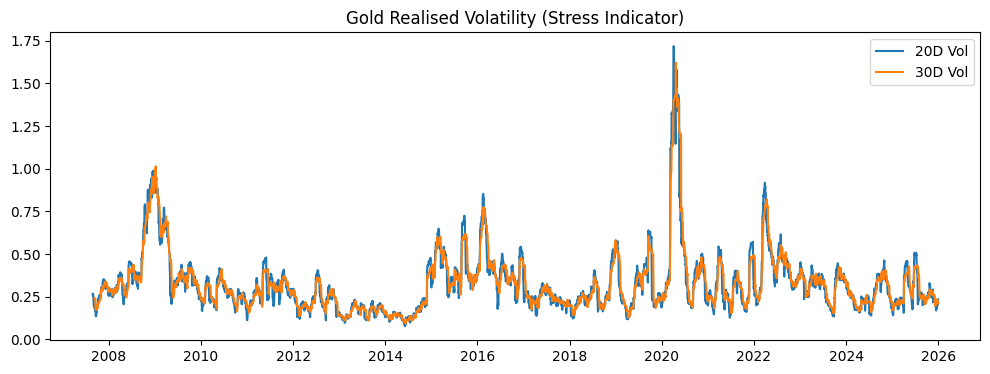

In [42]:
plt.figure(figsize=(12,4))
plt.plot(vol_20, label="20D Vol")
plt.plot(vol_30, label="30D Vol")
plt.legend()
plt.title("Gold Realised Volatility (Stress Indicator)")
plt.show()

R-squared

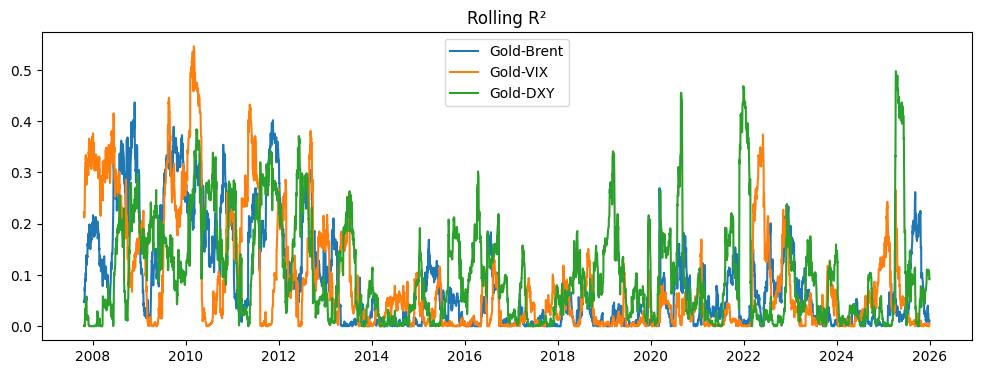

In [43]:
plt.figure(figsize=(12,4))

plt.plot(r2_brent, label="Gold-Brent")
plt.plot(r2_vix, label="Gold-VIX")
plt.plot(r2_dxy, label="Gold-DXY")

plt.title("Rolling R²")
plt.legend()
plt.show()

Correlation

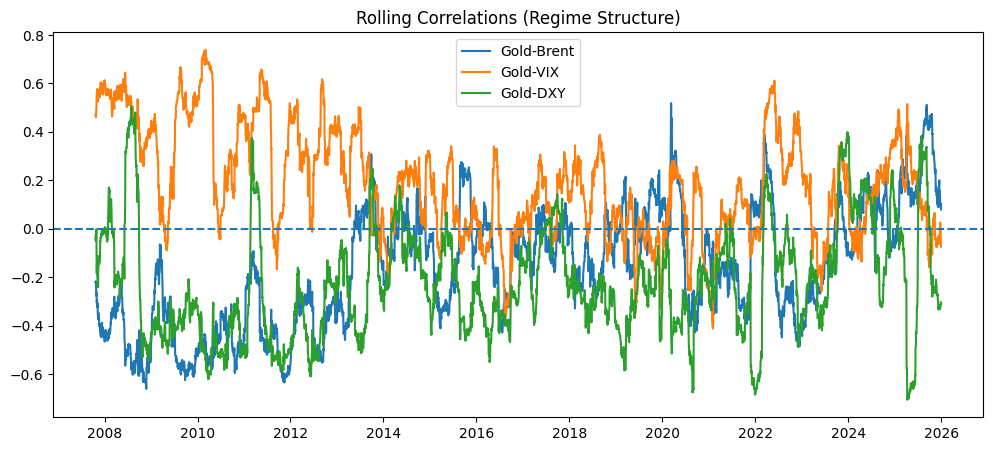

In [44]:
plt.figure(figsize=(12,5))
plt.plot(corr_gb, label="Gold-Brent")
plt.plot(corr_gv, label="Gold-VIX")
plt.plot(corr_gd, label="Gold-DXY")
plt.legend()
plt.title("Rolling Correlations (Regime Structure)")
plt.axhline(0, linestyle="--")
plt.show()

Alarm System

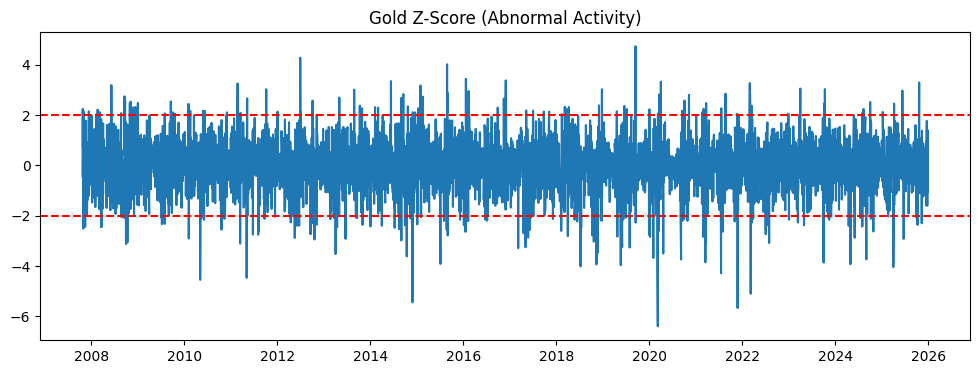

In [45]:
#GOLD Z-SCORE
plt.figure(figsize=(12,4))
plt.plot(gold_z)
plt.axhline(2, linestyle="--", color="red")
plt.axhline(-2, linestyle="--", color="red")
plt.title("Gold Z-Score (Abnormal Activity)")
plt.show()

Composite Risk Score

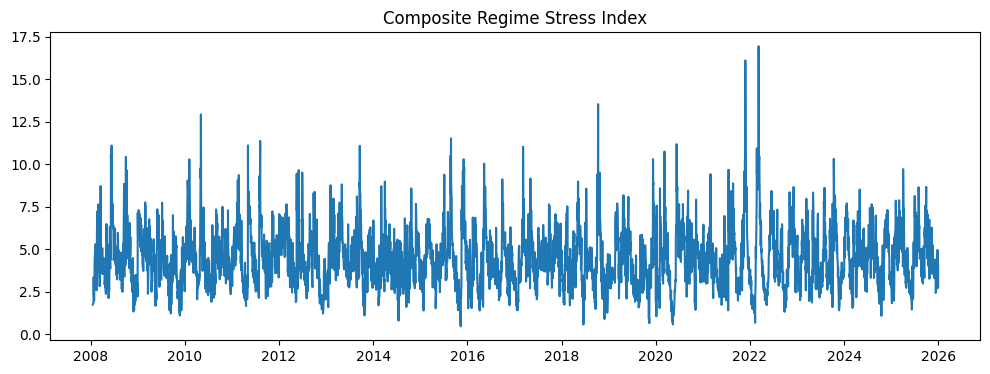

In [46]:
plt.figure(figsize=(12,4))
plt.plot(signal["RiskScore"])
plt.title("Composite Regime Stress Index")
plt.show()

Regime Visualiztion

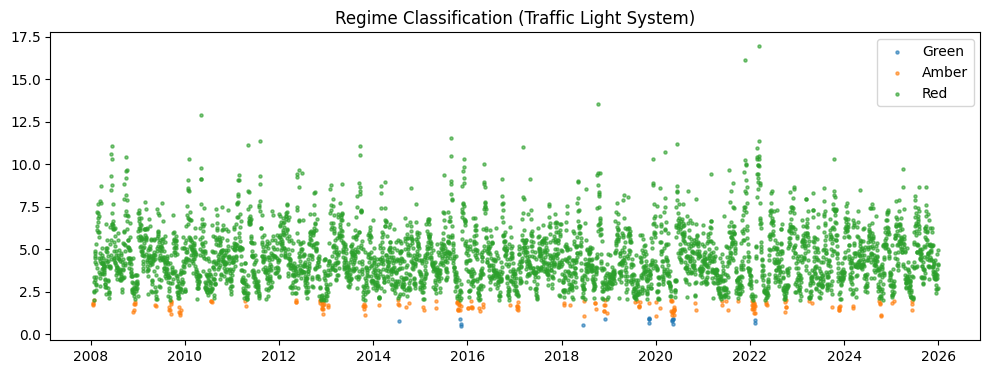

In [47]:
color_map = {
    "Green": "green",
    "Amber": "orange",
    "Red": "red"
}

plt.figure(figsize=(12,4))

for regime in ["Green", "Amber", "Red"]:
    subset = signal[signal["Regime"] == regime]
    plt.scatter(subset.index, subset["RiskScore"],
                label=regime, s=5, alpha=0.6)

plt.title("Regime Classification (Traffic Light System)")
plt.legend()
plt.show()

Crisis Highlight

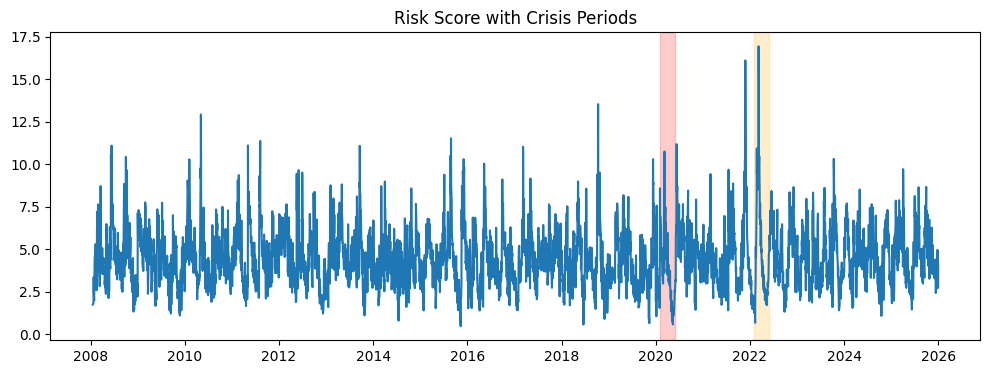

In [48]:
plt.figure(figsize=(12,4))
plt.plot(signal["RiskScore"])

plt.axvspan("2020-02-01", "2020-06-01", color="red", alpha=0.2)
plt.axvspan("2022-02-01", "2022-06-01", color="orange", alpha=0.2)

plt.title("Risk Score with Crisis Periods")
plt.show()